In [1]:
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF

sys.path.insert(0, "../../src")
from renewable_data_load import sim_name_dict, get_gwl_crossing_period

data_dir = Path("../../data/")


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
stats_cols = ["Sum", "Min", "Max", "Mean", "Median", "SD", "RMS"]
model_names = ["EC-Earth3", "MIROC6", "MPI-ESM1-2-HR", "TaiESM1"]

def parse_week_col(col_name):
    parts = col_name.split()
    return pd.Timestamp(f"{parts[2]}-01-01") + pd.Timedelta(weeks=int(parts[1]) - 1)

def parse_week_row(year, week):
    return pd.Timestamp(f"{int(year)}-01-01") + pd.Timedelta(weeks=int(week) - 1)

# Future model runs (S3, wide format, 2015-2060)
dfs = []
for model in model_names:
    url = f"s3://wfclimres/era/hydropower_generation/{model}_weekly_2015-2060_WEAP.csv"
    df = pd.read_csv(url, storage_options={"anon": True}, skiprows=3)
    df["model"] = model
    dfs.append(df)
merged_df = pd.concat(dfs, ignore_index=True).set_index(["model", "Hydropower facility"])
merged_df = merged_df.drop(index=stats_cols, level="Hydropower facility", errors="ignore")
time_cols = [c for c in merged_df.columns if c not in stats_cols]
timeseries_df = merged_df[time_cols]
timeseries_df.columns = pd.DatetimeIndex([parse_week_col(c) for c in timeseries_df.columns])
timeseries_df = timeseries_df.stack()
timeseries_df.index.names = ["model", "Hydropower facility", "time"]
ds = timeseries_df.to_xarray().rename({"Hydropower facility": "facility"})

# Baseline (S3, wide format, 1980-2020)
df_b = pd.read_csv(
    "s3://wfclimres/era/hydropower_generation/Baseline_weekly_1980-2020_WEAP.csv",
    storage_options={"anon": True}, skiprows=3,
).set_index("Hydropower facility")
df_b = df_b.drop(index=stats_cols, errors="ignore")
time_cols_b = [c for c in df_b.columns if c not in stats_cols]
df_b = df_b[time_cols_b].apply(pd.to_numeric, errors="coerce")
df_b.columns = pd.DatetimeIndex([parse_week_col(c) for c in df_b.columns])
stacked_b = df_b.stack()
stacked_b.index.names = ["Hydropower facility", "time"]
ds_baseline = stacked_b.to_xarray().rename({"Hydropower facility": "facility"})

# Historical model runs (local CSVs, long format, 1980-2020)
hist_dir = Path("historical_runs")
hist_dfs = []
for model in model_names:
    df = pd.read_csv(hist_dir / f"{model}_weekly_1980_2020_WEAP.csv", skiprows=5)
    tidx = pd.DatetimeIndex([parse_week_row(y, w) for y, w in zip(df["$Columns = Year"], df["Timestep"])])
    fac_df = df.drop(columns=["$Columns = Year", "Timestep"])
    fac_df.index = pd.Index(tidx, name="time")
    fac_df = fac_df.apply(pd.to_numeric, errors="coerce")
    stacked = fac_df.stack()
    stacked.index.names = ["time", "Hydropower facility"]
    stacked.name = model
    hist_dfs.append(stacked)
hist_combined = pd.concat(hist_dfs, keys=model_names, names=["model", "time", "Hydropower facility"])
hist_combined = hist_combined.reorder_levels(["model", "Hydropower facility", "time"])
ds_hist = hist_combined.to_xarray().rename({"Hydropower facility": "facility"})

# Merge: historical wins for overlapping period, then append future
ds_future_only = ds.sel(time=ds.time > ds_hist.time.max())
ds_model_combined = xr.concat([ds_hist, ds_future_only], dim="time")
ds_all = xr.concat([ds_model_combined, ds_baseline.expand_dims(model=["Gridmet"])], dim="model")

print(ds_all)


<xarray.DataArray (model: 5, facility: 216, time: 4212)> Size: 36MB
array([[[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.47286  ,
          2.73289  ,  3.06822  ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.494757 ,
          0.23628  ,  0.389772 ],
        ...,
        [ 2.03911  ,  0.034879 ,  0.115716 , ..., 16.2583   ,
         16.2583   , 18.5809   ],
        [ 9.16426  ,  7.36033  , 10.438    , ...,  5.23872  ,
          1.69222  ,  1.70679  ],
        [ 0.0599946,  0.0776756,  0.0807663, ...,  1.06351  ,
          1.03152  ,  1.14232  ]],

       [[ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 2.3107   ,  2.69502  ,  2.88189  , ...,  2.36339  ,
          2.60957  ,  2.92757  ],
        [ 0.338573 ,  0.341839 ,  0.325215 , ...,  0.437789 ,
          0.439338 ,  0.390338 ],
...
        [ 2.03911  ,  0.034879 ,  0.115716 , ...,

In [3]:
# ── Weekly SEI helpers ────────────────────────────────────

def _weekofyear(da):
    """Return week-of-year (1-52) from time coordinate, consistent with parse_week_row."""
    return (da.time.dt.dayofyear.values - 1) // 7 + 1


def unstack_time_to_week_year(data):
    """Decompose a weekly time dimension into (weekofyear, year)."""
    result = data.copy(deep=True)
    result = result.assign_coords(
        weekofyear=("time", _weekofyear(result)),
        year=("time", result.time.dt.year.values),
    )
    result = result.drop_vars("time").set_index(time=["weekofyear", "year"]).unstack()
    return result


def stack_week_year_to_time(data):
    """Reconstruct a weekly time dimension from (weekofyear, year)."""
    result = data.stack(time=["year", "weekofyear"])
    time_index = result.time.to_index()
    time_coords = [
        pd.Timestamp(year=int(y), month=1, day=1) + pd.Timedelta(weeks=int(w) - 1)
        for y, w in time_index
    ]
    result = result.reset_index("time", drop=True)
    result = result.assign_coords(time=("time", time_coords))
    return result.sortby("time")


def _compute_standardized_index(window_slice, target_value):
    """ECDF-based standardized index for a single (weekofyear, year) point."""
    if np.isnan(target_value):
        return np.nan
    samples = window_slice.flatten()
    samples = samples[~np.isnan(samples)]
    if len(samples) == 0:
        return np.nan
    ecdf_fn = ECDF(samples)
    fn_x = ecdf_fn(target_value)
    n = len(samples)
    f_rescaled = (n * fn_x + 1) / (n + 2)
    return float(norm.ppf(f_rescaled))


def compute_sei_weekly(reference_data, target_data, window_size=8):
    """
    Compute weekly SEI for hydro generation data.

    Parameters
    ----------
    reference_data : xr.DataArray
        Weekly time series to build ECDFs from (e.g. GWL 0.8 reference period).
    target_data : xr.DataArray
        Weekly time series to compute SEI for (full simulation period).
    window_size : int
        Rolling window in weeks (default 8, i.e. ±4 weeks around each week-of-year).

    Returns
    -------
    xr.DataArray with dims (weekofyear, year[, ...extra dims])
    """
    # Build rolling window over reference data → (weekofyear, year, window)
    ds_window = reference_data.rolling(time=window_size, center=True).construct("window")
    ds_window = ds_window.assign_coords(
        window=np.arange(1, window_size + 1),
        weekofyear=("time", _weekofyear(reference_data)),
        year=("time", reference_data.time.dt.year.values),
    )
    ds_window = ds_window.drop_vars("time").set_index(time=["weekofyear", "year"]).unstack()
    ds_window = ds_window.stack(sample=["window", "year"])  # flatten for ECDF

    # Reshape target into (weekofyear, year)
    ds_target = target_data.copy(deep=True)
    ds_target = ds_target.assign_coords(
        weekofyear=("time", _weekofyear(ds_target)),
        year=("time", ds_target.time.dt.year.values),
    )
    ds_target = ds_target.drop_vars("time").set_index(time=["weekofyear", "year"]).unstack()

    sei = xr.apply_ufunc(
        _compute_standardized_index,
        ds_window,
        ds_target,
        input_core_dims=[["sample"], []],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
        exclude_dims={"sample"},
    )
    sei.name = "sei"
    sei.attrs["long_name"] = "Standard Energy Index (weekly)"
    sei.attrs["window_size_weeks"] = window_size
    return sei

print("Weekly SEI helpers defined.")


Weekly SEI helpers defined.


In [8]:
ds_all.facility.values

array(['Alamo', 'Albeni Falls', 'Alcova', 'Alder', 'All American Hydro',
       'American Falls', 'Anderson Ranch', 'Arrow Lakes CAN', 'Balch 1',
       'Balch 2', 'Belden', 'Big Creek 1', 'Big Creek 2', 'Big Creek 2a',
       'Big Creek 3', 'Big Creek 4', 'Big Creek 8', 'Bliss', 'Blue Mesa',
       'Bonneville', 'Boundary', 'Box Canyon', 'Boysen Reservoir',
       'Brownlee', 'Bucks Creek', 'Butt Valley', 'C J Strike',
       'Cabinet Gorge', 'Camanche Reservoir', 'Camino', 'Canyon Ferry',
       'Caribou 1', 'Caribou 2', 'Carmen Smith', 'Castaic',
       'Castaic Lake', 'Cedar Falls', 'Chandler', 'Chelan',
       'Chicago Park', 'Chief Joseph', 'Cochrane', 'Colgate',
       'Collierville Powerhouse', 'Control Gorge', 'Coolidge Reservoir',
       'Copco 1 and 2', 'Cougar Dam and Reservoir', 'Cowlitz Falls',
       'Cresta', 'Cushman 1', 'Cushman 2', 'Cutler', 'Davis Dam',
       'Detroit', 'Devil Canyon', 'Dexter and Looking Point', 'Diablo',
       'Diamond Valley', 'Dion R Holm', 'D

In [12]:
# ── Single-facility test ───────────────────────────────────────────────────
test_facility = 'Boundary'
test_model = "EC-Earth3"

# Select full timeseries for this facility/model
da_full = ds_all.sel(facility=test_facility, model=test_model).dropna("time")

# Get GWL 0.8 reference period for this model
wrf_sim = sim_name_dict[test_model.lower()]
model_gcm = wrf_sim.split("_")[1]
ensemble  = wrf_sim.split("_")[2]
ref_start, ref_end = get_gwl_crossing_period(model_gcm, ensemble, 0.8)
print(f"{test_model}: GWL 0.8 reference period = {ref_start}–{ref_end}")

da_ref = da_full.sel(time=slice(f"{ref_start}-01-01", f"{ref_end}-12-31"))
print(f"Reference samples: {len(da_ref.time)}, Target samples: {len(da_full.time)}")


EC-Earth3: GWL 0.8 reference period = 1988–2017
Reference samples: 1559, Target samples: 4211


In [21]:
# Compute SEI
sei_test = compute_sei_weekly(da_ref, da_full, window_size=8)
print(sei_test)


<xarray.DataArray 'sei' (weekofyear: 52, year: 81)> Size: 17kB
array([[-2.6354184 , -2.6354184 , -2.6354184 , ..., -2.6354184 ,
        -1.8895099 , -2.6354184 ],
       [-2.636841  , -2.636841  , -1.9581773 , ..., -2.392448  ,
        -1.2330068 , -2.392448  ],
       [-2.6382573 , -0.88714653, -1.5341206 , ..., -1.7316644 ,
        -0.64849216, -1.7316644 ],
       ...,
       [-2.3955045 , -1.961742  ,  0.5887685 , ..., -1.1942885 ,
        -2.3955045 , -2.2430086 ],
       [-1.8931845 , -1.2133396 ,  1.1708311 , ..., -0.56070304,
        -1.6448536 , -1.3305615 ],
       [-1.6428286 , -1.603671  ,  1.0518093 , ..., -0.6581212 ,
        -1.7785485 , -1.4084569 ]], shape=(52, 81), dtype=float32)
Coordinates:
  * weekofyear  (weekofyear) int64 416B 1 2 3 4 5 6 7 8 ... 46 47 48 49 50 51 52
  * year        (year) int64 648B 1980 1981 1982 1983 ... 2057 2058 2059 2060
    facility    <U8 32B 'Boundary'
    model       <U9 36B 'EC-Earth3'
Attributes:
    long_name:          Standard Energ

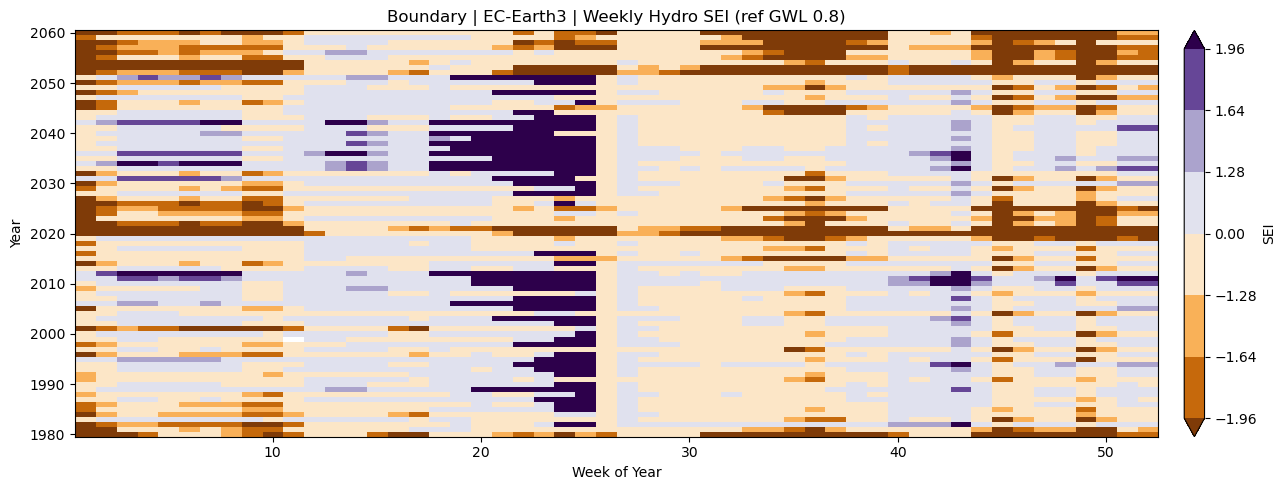

In [22]:
# Plot: SEI heatmap (week-of-year × year), matching demand SEI style
fig, ax = plt.subplots(figsize=(14, 5))
xr.plot.imshow(
    sei_test.T,   # transpose so year is y-axis, weekofyear is x-axis
    ax=ax,
    levels=[-1.96, -1.64, -1.28, 0, 1.28, 1.64, 1.96],
    cmap="PuOr",
    cbar_kwargs={"pad": 0.02, "label": "SEI"},
)
ax.set_title(f"{test_facility} | {test_model} | Weekly Hydro SEI (ref GWL {0.8})")
ax.set_xlabel("Week of Year")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()


In [ ]:
# Preview saving output for the test facility
# Once happy with the result, uncomment and run the full loop below

sei_ts = stack_week_year_to_time(sei_test)

output_dir = data_dir / "SEI"
output_dir.mkdir(parents=True, exist_ok=True)

save_path = output_dir / f"hydro_{test_model}_gwlref0.8_{test_facility}_weekly_SEI.nc"
# sei_ts.to_netcdf(save_path)
print(f"Would save to: {save_path}")
print(sei_ts)


In [24]:
# ── Full loop: compute + save SEI for all facilities and models ─────────────
# Uncomment and run once satisfied with the single-facility test above.

reference_gwl = 0.8
all_models = list(ds_all.model.values)   # includes "Gridmet"
all_facilities = list(ds_all.facility.values)

fig_dir = Path("figures/hydro_sei")
fig_dir.mkdir(parents=True, exist_ok=True)
output_dir = data_dir / "SEI"
output_dir.mkdir(parents=True, exist_ok=True)

for model in all_models:
    # Reference period: GWL 0.8 for WRF models, full period for Gridmet
    if model == "Gridmet":
        da_model = ds_all.sel(model=model).dropna("time", how="all")
        ref_start = int(da_model.time.dt.year.min())
        ref_end   = int(da_model.time.dt.year.max())
    else:
        wrf_sim  = sim_name_dict[model.lower()]
        gcm      = wrf_sim.split("_")[1]
        ensemble = wrf_sim.split("_")[2]
        ref_start, ref_end = get_gwl_crossing_period(gcm, ensemble, reference_gwl)

    print(f"\n{model}: reference {ref_start}–{ref_end}")

    facility_sei_list = []

    for facility in all_facilities:
        da_full = ds_all.sel(model=model, facility=facility).dropna("time")
        if len(da_full.time) == 0:
            continue

        da_ref = da_full.sel(time=slice(f"{ref_start}-01-01", f"{ref_end}-12-31"))
        sei = compute_sei_weekly(da_ref, da_full, window_size=8)

        # Plot
        fig, ax = plt.subplots(figsize=(14, 5))
        xr.plot.imshow(
            sei.T, ax=ax,
            levels=[-1.96, -1.64, -1.28, 0, 1.28, 1.64, 1.96],
            cmap="PuOr_r", cbar_kwargs={"pad": 0.02, "label": "SEI"},
        )
        ax.set_title(f"{facility} | {model} | Weekly Hydro SEI (ref GWL {reference_gwl})")
        ax.set_xlabel("Week of Year"); ax.set_ylabel("Year")
        plt.tight_layout()
        fig_path = fig_dir / f"{facility}_{model}_gwlref{reference_gwl}_weekly_SEI.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.close()

        # Collect timeseries for this facility
        sei_ts = stack_week_year_to_time(sei)
        sei_ts = sei_ts.expand_dims(facility=[facility])
        facility_sei_list.append(sei_ts)

    # Concatenate all facilities and save one NetCDF per model
    if facility_sei_list:
        sei_model = xr.concat(facility_sei_list, dim="facility")
        save_path = output_dir / f"hydro_{model}_gwlref{reference_gwl}_weekly_SEI.nc"
        sei_model.to_netcdf(save_path)
        print(f"  Saved {len(facility_sei_list)} facilities → {save_path.name}")



EC-Earth3: reference 1988–2017
  Saved 216 facilities → hydro_EC-Earth3_gwlref0.8_weekly_SEI.nc

MIROC6: reference 1997–2026
  Saved 216 facilities → hydro_MIROC6_gwlref0.8_weekly_SEI.nc

MPI-ESM1-2-HR: reference 1981–2010
  Saved 216 facilities → hydro_MPI-ESM1-2-HR_gwlref0.8_weekly_SEI.nc

TaiESM1: reference 1996–2025
  Saved 216 facilities → hydro_TaiESM1_gwlref0.8_weekly_SEI.nc

Gridmet: reference 1980–2020
  Saved 216 facilities → hydro_Gridmet_gwlref0.8_weekly_SEI.nc


In [25]:

# ── Compute daily drought masks from saved weekly SEI files ─────────────────
# Threshold: SEI < -1.28 (approx. 10th percentile) → drought
# Weekly masks are expanded to daily resolution via ffill:
# each week's True/False value is propagated forward for 7 days.

reference_gwl = 0.8
sei_dir = data_dir / "SEI"
mask_dir = data_dir / "drought_masks"
mask_dir.mkdir(parents=True, exist_ok=True)

drought_threshold = -1.28

sei_files = sorted(sei_dir.glob(f"hydro_*_gwlref{reference_gwl}_weekly_SEI.nc"))
print(f"Found {len(sei_files)} SEI files:")
for f in sei_files:
    print(f"  {f.name}")

for sei_file in sei_files:
    # Parse model name from filename: hydro_{model}_gwlref{gwl}_weekly_SEI.nc
    stem = sei_file.stem  # e.g. "hydro_EC-Earth3_gwlref0.8_weekly_SEI"
    model = stem.removeprefix("hydro_").removesuffix(f"_gwlref{reference_gwl}_weekly_SEI")
    print(f"\nProcessing {model}...")

    sei_model = xr.open_dataarray(sei_file)

    # Binary drought mask: 1 = drought (low generation), 0 = normal
    drought_mask_weekly = xr.where(sei_model < drought_threshold, 1, 0)
    drought_mask_weekly.name = "hydro_mask"

    # Expand weekly → daily via ffill
    # Each weekly timestamp (Jan 1, Jan 8, ...) is the start of the week;
    # the value is propagated forward through all 7 days of that week.
    t0 = pd.Timestamp(sei_model.time.values[0])
    t1 = pd.Timestamp(sei_model.time.values[-1]) + pd.Timedelta(days=6)
    daily_index = pd.date_range(start=t0, end=t1, freq="D")

    drought_mask_daily = drought_mask_weekly.reindex(time=daily_index, method="ffill")

    # Add metadata
    drought_mask_daily.attrs = {
        "resource": "hydropower",
        "variable": "generation",
        "threshold": drought_threshold,
        "threshold_description": "SEI < -1.28 (approx. 10th percentile)",
        "model": model,
        "reference_gwl": float(reference_gwl),
        "temporal_resolution": "daily (upsampled from weekly SEI via ffill)",
        "description": (
            "Binary hydro drought mask: 1 = low generation drought (SEI < -1.28), "
            "0 = normal. Weekly SEI expanded to daily by forward-filling each "
            "week's value across all 7 days of that week."
        ),
    }

    # Clear encoding to avoid codec conflicts
    drought_mask_daily = drought_mask_daily.load()
    drought_mask_daily.encoding = {}
    for coord in drought_mask_daily.coords:
        drought_mask_daily.coords[coord].encoding = {}

    # Save as zarr (matching demand drought mask format)
    mask_path = mask_dir / f"hydro_gwlref{reference_gwl}_{model}_ts_drought_mask.zarr"
    encoding = {"hydro_mask": {"dtype": "int32"}}
    drought_mask_daily.to_zarr(mask_path, encoding=encoding, mode="w", consolidated=True)
    print(f"  Shape: {dict(zip(drought_mask_daily.dims, drought_mask_daily.shape))}")
    print(f"  Time: {pd.Timestamp(drought_mask_daily.time.values[0]).date()} → {pd.Timestamp(drought_mask_daily.time.values[-1]).date()}")
    print(f"  Saved → {mask_path.name}")


Found 5 SEI files:
  hydro_EC-Earth3_gwlref0.8_weekly_SEI.nc
  hydro_Gridmet_gwlref0.8_weekly_SEI.nc
  hydro_MIROC6_gwlref0.8_weekly_SEI.nc
  hydro_MPI-ESM1-2-HR_gwlref0.8_weekly_SEI.nc
  hydro_TaiESM1_gwlref0.8_weekly_SEI.nc

Processing EC-Earth3...
  Shape: {'facility': 216, 'time': 29584}
  Time: 1980-01-01 → 2060-12-29
  Saved → hydro_gwlref0.8_EC-Earth3_ts_drought_mask.zarr

Processing Gridmet...
  Shape: {'facility': 216, 'time': 14974}
  Time: 1980-01-01 → 2020-12-29
  Saved → hydro_gwlref0.8_Gridmet_ts_drought_mask.zarr

Processing MIROC6...
  Shape: {'facility': 216, 'time': 29584}
  Time: 1980-01-01 → 2060-12-29
  Saved → hydro_gwlref0.8_MIROC6_ts_drought_mask.zarr

Processing MPI-ESM1-2-HR...
  Shape: {'facility': 216, 'time': 29584}
  Time: 1980-01-01 → 2060-12-29
  Saved → hydro_gwlref0.8_MPI-ESM1-2-HR_ts_drought_mask.zarr

Processing TaiESM1...
  Shape: {'facility': 216, 'time': 29584}
  Time: 1980-01-01 → 2060-12-29
  Saved → hydro_gwlref0.8_TaiESM1_ts_drought_mask.zarr
